### Goal



Test the perfomance of the following time series models as the baseline model for short-term prediction:
- [Holt-Winters (Triple Exponential Smoothing)](https://www.statsmodels.org/devel/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html)
- [ARIMA](https://www.statsmodels.org/devel/generated/statsmodels.tsa.arima.model.ARIMA.html#statsmodels.tsa.arima.model.ARIMA)

We will first use the category `hep-ph` ("High Energy Physics - Phenomenology") as a testing case, and then do the model comparison for all the categories.

### Data processing and set-up


In [ ]:
import pandas, numpy, matplotlib, seaborn, sklearn, statsmodels, prophet
print("All packages imported successfully!")

All packages imported successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from seaborn import set_style
from sklearn.metrics import mean_squared_error

set_style("whitegrid")

We load the data from `data/arxiv-totals.parquet` and set up our training data set from 01/01/2001 (Monday) to 03/14/2025 (Monday), and testing data set to 03/17/2025 (Monday).

In [ ]:
df = pd.read_parquet("../data/arxiv-totals.parquet")

df_train = df[
    (df.index >= pd.Timestamp(2001, 1, 1)) & (df.index <= pd.Timestamp(2025, 3, 14))
]
df_test = df[df.index >= pd.Timestamp(2025, 3, 17)]

In [ ]:
print(df.columns)
print(df_train.shape, df_test.shape)
print(df.head())

Index(['hep-th', 'physics.pop-ph', 'math.LO', 'math.FA', 'math.MG', 'cs.CC',
       'math.CO', 'math.PR', 'math.DS', 'cs.GR',
       ...
       'econ.EM', 'stat.CO', 'stat.OT', 'q-fin.EC', 'eess.SY', 'econ.GN',
       'eess.AS', 'eess.IV', 'eess.SP', 'q-fin.MF'],
      dtype='object', length=158)
(6315, 158) (20, 158)
            hep-th  physics.pop-ph  math.LO  math.FA  math.MG  cs.CC  math.CO  \
date                                                                            
1986-04-28     1.0             1.0      0.0      0.0      0.0    0.0      0.0   
1988-11-14     1.0             0.0      0.0      0.0      0.0    0.0      0.0   
1989-04-17     0.0             0.0      1.0      0.0      0.0    0.0      0.0   
1989-10-27     0.0             0.0      0.0      3.0      3.0    0.0      0.0   
1989-11-10     0.0             0.0      0.0      1.0      1.0    0.0      0.0   

            math.PR  math.DS  cs.GR  ...  econ.EM  stat.CO  stat.OT  q-fin.EC  \
date                           

This indicates that the time series has seasonality, with season of a week. Other categories exhibit similar correlograms, so effective models should likely take weekly seasonality into account (notice that the seasonal parameter should be 5 instead of 7 since the papers are only submitted on business days). Looking at the graphs, there is also a global trend to take into account.

We will use [statsmodels](https://www.statsmodels.org/stable/index.html) as our choice of time series library (Install the module `statsmodels` by using Anaconda `conda install -c conda-forge statsmodels`). In partucular, see [Time Series analysis `tsa`](https://www.statsmodels.org/devel/tsa.html).

In [ ]:
## Importing statsmodels to check that we have it installed
import statsmodels as sm

In [ ]:
## printing the statsmodels version
print(sm.__version__)

0.14.4


### Model tuning

We now prepare a 5-fold validation. We take a gap of 5 business days between train and validation splits, and we take a test size of 15 business days (our forecasting horizon is 5 business days). That is, we set up our cross-validation as:
- `n_splits`=5
- `test_size`=15
- `max_train_size`=150

Due to the runtime issues of auto_ARIMA, we will only compare the following models:
- Naive forecast (dummy)
- Exponential Smoothing (non-CV)
- Exponential Smoothing (CV)
- Manual SARIMA
- Prophet ([Facebook Prophet](http://facebook.github.io/prophet/))


Our grid search for smoothing parameters of EST is as the following:

| Config | α (level) | β (trend) | γ (seasonal) | Intuition                                                                 |
| ------ | --------- | --------- | ------------ | ------------------------------------------------------------------------- |
| #1     | 0.1       | 0.1       | 0.1          | Very **stable** model — slow updates to all components                    |
| #2     | 0.1       | 0.1       | 0.8          | Keeps **level/trend stable**, allows **seasonal** pattern to vary quickly |
| #3     | 0.3       | 0.1       | 0.3          | Slightly more responsive level & seasonality, but trend still stable      |
| #4     | 0.5       | 0.3       | 0.5          | **Balanced responsiveness** — a middle ground, adapts fairly quickly      |


For manual SARIMA, a reasonable set of hyperparameters are: 
- `(0,0,0) (0,1,0,5)`
- `(0,0,0) (1,1,0,5)`
- `(0,0,0) (0,1,1,5)`
- `(0,0,0) (1,1,1,5)`  

The intuitive explanation is the following: ???

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from prophet import Prophet
import pandas as pd
import numpy as np
import json
import warnings

warnings.filterwarnings("ignore")

# Load categories
with open("../data/arxiv-categories.json", "r") as f:
    arxiv_categories_descriptions = json.load(f)
categories = sorted([cat["tag"] for cat in arxiv_categories_descriptions])

# Define SARIMA parameter sets for grid search
sarima_param_sets = [(0,1,0,5), (1,1,0,5), (0,1,1,5), (1,1,1,5)]

# Define Exponential Smoothing structures and smoothing parameters
est_structures = [
    {"trend": None, "seasonal": "add"},
    {"trend": None, "seasonal": "mul"},
    {"trend": "add", "seasonal": "add"},
    {"trend": "add", "seasonal": "mul"}
]
smoothing_grid = [
    {"level": 0.1, "trend": 0.1, "seasonal": 0.1},
    {"level": 0.1, "trend": 0.1, "seasonal": 0.8},
    {"level": 0.3, "trend": 0.1, "seasonal": 0.3},
    {"level": 0.5, "trend": 0.3, "seasonal": 0.5},
]

# Prepare CV splits
ts_cv = TimeSeriesSplit(n_splits=5, test_size=15, max_train_size=150)
splits = [(train_idx, test_idx) for train_idx, test_idx in ts_cv.split(df_train)]

# Initialize result containers
cv_results_dict = {}
cv_best_params_dict = {}

df_train = df_train.asfreq("B")  # Ensure business day frequency

for category in categories:
    print(f"Tuning category: {category}")
    best_params = {}
    cv_results = {}

    # Dummy model
    dummy_rmses = []
    for train_idx, test_idx in splits:
        y_train = df_train.iloc[train_idx][category].fillna(0)
        y_test = df_train.iloc[test_idx][category].fillna(0)
        dummy_preds = np.full_like(y_test, y_train.mean())
        rmse = np.sqrt(mean_squared_error(y_test, dummy_preds))
        dummy_rmses.append(rmse)
    train_mean = df_train[category].fillna(0).mean()
    cv_results["Dummy"] = np.nanmean(dummy_rmses) / train_mean
    best_params["Dummy"] = {"value": y_train.mean()}

    # EST_NCV (manual smoothing)
    best_est_ncv_rmse = np.inf
    best_est_ncv_config = None
    for struct in est_structures:
        for smooth in smoothing_grid:
            rmses = []
            for train_idx, test_idx in splits:
                y_train = df_train.iloc[train_idx][category].fillna(0)
                y_test = df_train.iloc[test_idx][category].fillna(0)
                try:
                    model = ExponentialSmoothing(
                        y_train,
                        trend=struct["trend"],
                        seasonal=struct["seasonal"],
                        seasonal_periods=5
                    ).fit(
                        smoothing_level=smooth["level"],
                        smoothing_trend=smooth["trend"],
                        smoothing_seasonal=smooth["seasonal"],
                        optimized=False
                    )
                    preds = model.forecast(len(y_test))
                    rmse = np.sqrt(mean_squared_error(y_test, preds))
                    rmses.append(rmse)
                except:
                    rmses.append(np.nan)
            avg_rmse = np.nanmean(rmses)
            if avg_rmse < best_est_ncv_rmse:
                best_est_ncv_rmse = avg_rmse
                best_est_ncv_config = {
                    "trend": struct["trend"],
                    "seasonal": struct["seasonal"],
                    "smoothing_level": smooth["level"],
                    "smoothing_trend": smooth["trend"],
                    "smoothing_seasonal": smooth["seasonal"]
                }
    cv_results["EST_NCV"] = best_est_ncv_rmse / train_mean
    best_params["EST_NCV"] = best_est_ncv_config

    # EST_CV (auto smoothing)
    best_est_cv_rmse = np.inf
    best_est_cv_config = None
    for struct in est_structures:
        rmses = []
        for train_idx, test_idx in splits:
            y_train = df_train.iloc[train_idx][category].fillna(0)
            y_test = df_train.iloc[test_idx][category].fillna(0)
            try:
                model = ExponentialSmoothing(
                    y_train,
                    trend=struct["trend"],
                    seasonal=struct["seasonal"],
                    seasonal_periods=5
                ).fit(optimized=True)
                preds = model.forecast(len(y_test))
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                rmses.append(rmse)
            except:
                rmses.append(np.nan)
        avg_rmse = np.nanmean(rmses)
        if avg_rmse < best_est_cv_rmse:
            best_est_cv_rmse = avg_rmse
            best_est_cv_config = {
                "trend": struct["trend"],
                "seasonal": struct["seasonal"]
            }
    cv_results["EST_CV"] = best_est_cv_rmse / train_mean
    best_params["EST_CV"] = best_est_cv_config

    # SARIMA_CV (manual seasonal order)
    best_sarima_rmse = np.inf
    best_sarima_config = None
    for seasonal_order in sarima_param_sets:
        rmses = []
        for train_idx, test_idx in splits:
            y_train = df_train.iloc[train_idx][category].fillna(0)
            y_test = df_train.iloc[test_idx][category].fillna(0)
            try:
                model = ARIMA(y_train, order=(0, 0, 0), seasonal_order=seasonal_order)
                fitted = model.fit()
                preds = fitted.forecast(steps=len(y_test))
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                rmses.append(rmse)
            except:
                rmses.append(np.nan)
        avg_rmse = np.nanmean(rmses)
        if avg_rmse < best_sarima_rmse:
            best_sarima_rmse = avg_rmse
            best_sarima_config = {"seasonal_order": seasonal_order}
    cv_results["SARIMA_CV"] = best_sarima_rmse / train_mean
    best_params["SARIMA_CV"] = best_sarima_config

    # Store all results
    cv_results_dict[category] = cv_results
    cv_best_params_dict[category] = best_params


Tuning category: astro-ph.CO
Tuning category: astro-ph.EP
Tuning category: astro-ph.EP
Tuning category: astro-ph.GA
Tuning category: astro-ph.GA
Tuning category: astro-ph.HE
Tuning category: astro-ph.HE
Tuning category: astro-ph.IM
Tuning category: astro-ph.IM
Tuning category: astro-ph.SR
Tuning category: astro-ph.SR
Tuning category: cond-mat.dis-nn
Tuning category: cond-mat.dis-nn
Tuning category: cond-mat.mes-hall
Tuning category: cond-mat.mes-hall
Tuning category: cond-mat.mtrl-sci
Tuning category: cond-mat.mtrl-sci
Tuning category: cond-mat.other
Tuning category: cond-mat.other
Tuning category: cond-mat.quant-gas
Tuning category: cond-mat.quant-gas
Tuning category: cond-mat.soft
Tuning category: cond-mat.soft
Tuning category: cond-mat.stat-mech
Tuning category: cond-mat.stat-mech
Tuning category: cond-mat.str-el
Tuning category: cond-mat.str-el
Tuning category: cond-mat.supr-con
Tuning category: cond-mat.supr-con
Tuning category: cs.AI
Tuning category: cs.AI
Tuning category: cs.AR


We print out and save the CV RMSE results `cv_results_dict` and the best parameters `cv_best_params_dict` for each cateogry.

In [ ]:
import pandas as pd
import json

# Convert results to DataFrame
results_df = pd.DataFrame.from_dict(cv_results_dict, orient="index")

# Print results
print("📊 Cross-Validation RMSE Results (normalized by train mean):")
print(results_df.round(3))  # Rounded for readability

# Print best parameters
print("\n🔧 Best Parameters for Each Category:")
for category, model_dict in cv_best_params_dict.items():
    print(f"\nCategory: {category}")
    for model_name, params in model_dict.items():
        print(f"  {model_name}: {params}")

# Save results to CSV
results_df.to_csv("cv_results.csv")

# Save best parameters to JSON
with open("cv_best_params.json", "w") as f:
    json.dump(cv_best_params_dict, f, indent=2)

print("\n✅ Results saved to 'cv_results.csv' and 'cv_best_params.json'.")


📊 Cross-Validation RMSE Results (normalized by train mean):
             Dummy  EST_NCV  EST_CV  SARIMA_CV
astro-ph.CO  0.511    0.562   0.570      0.466
astro-ph.EP  0.857    0.839   0.849      0.846
astro-ph.GA  0.780    0.816   0.816      0.793
astro-ph.HE  0.731    0.725   0.760      0.707
astro-ph.IM  0.979    0.959   0.931      0.929
...            ...      ...     ...        ...
stat.CO      1.350    1.399   1.351      1.331
stat.ME      1.267    1.070   1.075      1.002
stat.ML      1.041    0.856   0.816      0.725
stat.OT      3.075    3.364   3.084      3.097
stat.TH      0.914    0.926   0.907      0.872

[155 rows x 4 columns]

🔧 Best Parameters for Each Category:

Category: astro-ph.CO
  Dummy: {'value': np.float64(16.973333333333333)}
  EST_NCV: {'trend': None, 'seasonal': 'add', 'smoothing_level': 0.1, 'smoothing_trend': 0.1, 'smoothing_seasonal': 0.1}
  EST_CV: {'trend': None, 'seasonal': 'add'}
  SARIMA_CV: {'seasonal_order': (0, 1, 1, 5)}

Category: astro-ph.EP
  Dum

### Model testing

For each category and each method, we run the model with the best parameters on `test_size=15`.

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

test_results_dict = {}

# Ensure business day frequency
df_train = df_train.asfreq("B")
df_test = df_test.asfreq("B")

for category in categories:
    print(f"Testing category: {category}")

    # Prepare train and test data
    y_train = df_train[category].fillna(0)
    y_test = df_test[category].fillna(0)
    train_mean = y_train.mean()
    
    best_params = cv_best_params_dict[category]
    test_results = {}

    # Dummy
    dummy_value = best_params["Dummy"]["value"]
    dummy_preds = np.full_like(y_test, dummy_value)
    dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_preds))
    test_results["Dummy"] = dummy_rmse / train_mean

    # EST_NCV (manual smoothing)
    try:
        p = best_params["EST_NCV"]
        model = ExponentialSmoothing(
            y_train,
            trend=p["trend"],
            seasonal=p["seasonal"],
            seasonal_periods=5
        ).fit(
            smoothing_level=p["smoothing_level"],
            smoothing_trend=p["smoothing_trend"],
            smoothing_seasonal=p["smoothing_seasonal"],
            optimized=False
        )
        preds = model.forecast(len(y_test))
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        test_results["EST_NCV"] = rmse / train_mean
    except:
        test_results["EST_NCV"] = np.nan

    # EST_CV (auto smoothing)
    try:
        p = best_params["EST_CV"]
        model = ExponentialSmoothing(
            y_train,
            trend=p["trend"],
            seasonal=p["seasonal"],
            seasonal_periods=5
        ).fit(optimized=True)
        preds = model.forecast(len(y_test))
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        test_results["EST_CV"] = rmse / train_mean
    except:
        test_results["EST_CV"] = np.nan

    # SARIMA_CV (manual seasonal order)
    try:
        seasonal_order = tuple(best_params["SARIMA_CV"]["seasonal_order"])
        model = ARIMA(y_train, order=(0, 0, 0), seasonal_order=seasonal_order)
        fitted = model.fit()
        preds = fitted.forecast(steps=len(y_test))
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        test_results["SARIMA_CV"] = rmse / train_mean
    except:
        test_results["SARIMA_CV"] = np.nan

    # Save test results
    test_results_dict[category] = test_results


Testing category: astro-ph.CO
Testing category: astro-ph.EP
Testing category: astro-ph.EP
Testing category: astro-ph.GA
Testing category: astro-ph.GA
Testing category: astro-ph.HE
Testing category: astro-ph.HE
Testing category: astro-ph.IM
Testing category: astro-ph.IM
Testing category: astro-ph.SR
Testing category: astro-ph.SR
Testing category: cond-mat.dis-nn
Testing category: cond-mat.dis-nn
Testing category: cond-mat.mes-hall
Testing category: cond-mat.mes-hall
Testing category: cond-mat.mtrl-sci
Testing category: cond-mat.mtrl-sci
Testing category: cond-mat.other
Testing category: cond-mat.other
Testing category: cond-mat.quant-gas
Testing category: cond-mat.quant-gas
Testing category: cond-mat.soft
Testing category: cond-mat.soft
Testing category: cond-mat.stat-mech
Testing category: cond-mat.stat-mech
Testing category: cond-mat.str-el
Testing category: cond-mat.str-el
Testing category: cond-mat.supr-con
Testing category: cond-mat.supr-con
Testing category: cs.AI
Testing category

We analyze the `test_results_dict` in the following aspects:
- Model performance summary
- Rank-based comparison
- Visual heatmap
- Best model counts
- Average performance plot
- Hardest categories


📋 Summary Statistics (Normalized RMSE per Model):
            mean    std    min    max
SARIMA_CV  1.373  0.914  0.000  4.941
EST_CV     1.460  0.948  0.270  4.817
Dummy      1.497  0.974  0.202  5.111
EST_NCV    1.595  1.164  0.278  8.282

🏆 Average Rank per Model:
EST_CV       1.87
SARIMA_CV    2.05
Dummy        2.84
EST_NCV      2.88
dtype: float64


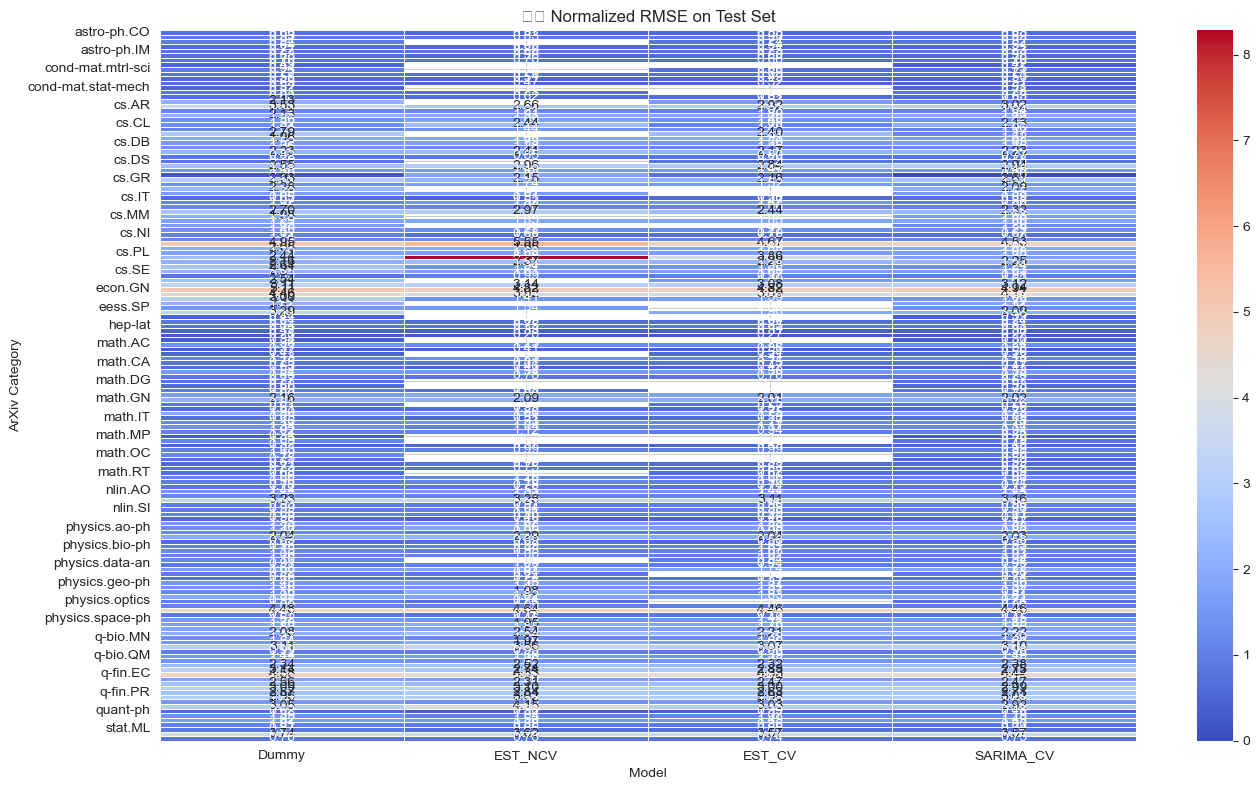


🥇 Best Model Count per Category:
SARIMA_CV    51
EST_CV       50
EST_NCV      29
Dummy        25
Name: count, dtype: int64


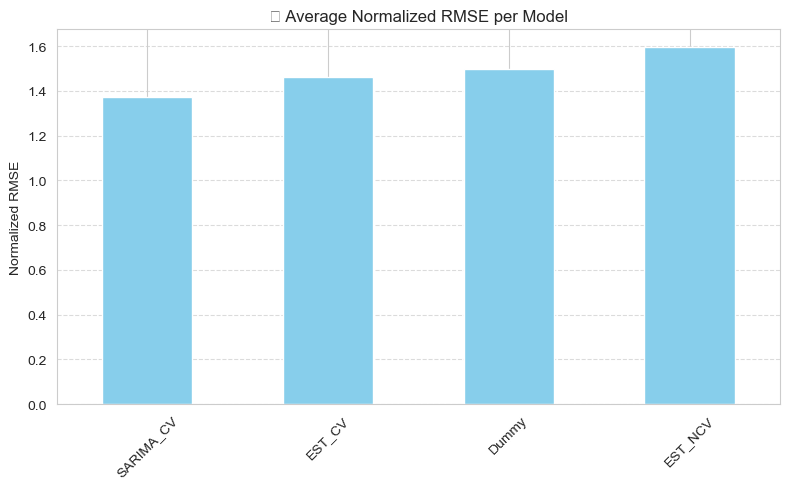


⚠️ Most Challenging Categories (Highest Avg RMSE):
cs.OS             4.925
econ.GN           4.923
physics.pop-ph    4.512
q-fin.EC          4.419
econ.TH           4.110
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
results_df = pd.DataFrame.from_dict(test_results_dict, orient="index")

# 1. Summary Statistics
summary = results_df.describe().T.sort_values("mean")
print("\n📋 Summary Statistics (Normalized RMSE per Model):")
print(summary[["mean", "std", "min", "max"]].round(3))

# 2. Average Rank per Model
ranks = results_df.rank(axis=1, method="min")
average_ranks = ranks.mean().sort_values()
print("\n🏆 Average Rank per Model:")
print(average_ranks.round(2))

# 3. Heatmap of Normalized RMSEs
plt.figure(figsize=(14, 8))
sns.heatmap(results_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("🗺️ Normalized RMSE on Test Set")
plt.xlabel("Model")
plt.ylabel("ArXiv Category")
plt.tight_layout()
plt.show()

# 4. Best Model per Category
best_model_counts = results_df.idxmin(axis=1).value_counts()
print("\n🥇 Best Model Count per Category:")
print(best_model_counts)

# 5. Bar Plot of Average RMSE per Model
plt.figure(figsize=(8, 5))
results_df.mean().sort_values().plot(kind='bar', color='skyblue')
plt.title("📊 Average Normalized RMSE per Model")
plt.ylabel("Normalized RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Most Difficult Categories
difficult_cats = results_df.mean(axis=1).sort_values(ascending=False).head(5)
print("\n⚠️ Most Challenging Categories (Highest Avg RMSE):")
print(difficult_cats.round(3))

# Save results
results_df.to_csv("test_results.csv")
summary.to_csv("test_summary_stats.csv")
ranks.to_csv("test_model_ranks.csv")


We compare `cv_results_dict` (from tuning step) and `test_results_dict` (from final evaluation step) side-by-side and focus on the following:

- Test vs CV Mean RMSE: overall generalization performance

- Difference (Test - CV): raw overfitting gap

- Ratio (Test / CV): normalized generalization factor

- Bar Plot: visual model stability


📉 Mean RMSE (CV):
Dummy        1.475
EST_CV       1.390
EST_NCV      1.408
SARIMA_CV    1.402
dtype: float64

📈 Mean RMSE (Test):
Dummy        1.497
EST_CV       1.460
EST_NCV      1.595
SARIMA_CV    1.373
dtype: float64

🔍 Difference (Test - CV):
Dummy        0.022
EST_CV      -0.001
EST_NCV      0.104
SARIMA_CV   -0.029
dtype: float64

📊 Ratio (Test / CV):
Dummy        1.03
EST_CV       1.00
EST_NCV      1.05
SARIMA_CV    1.01
dtype: float64


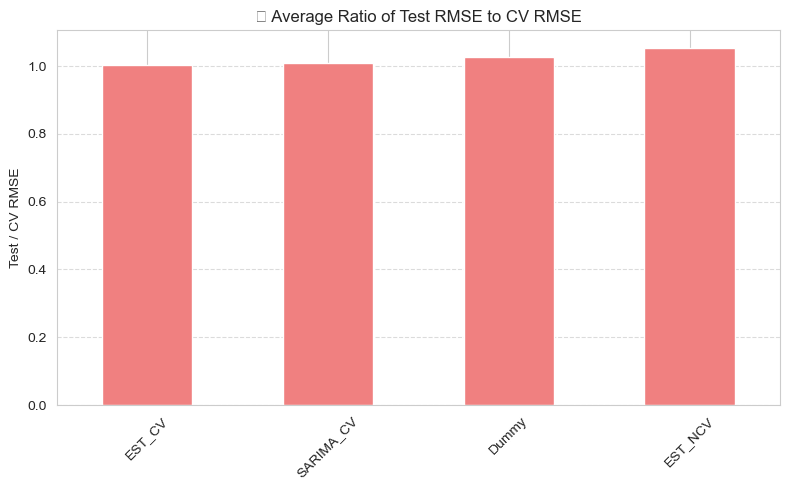

In [ ]:
import pandas as pd

# Convert both dicts to DataFrames
cv_df = pd.DataFrame.from_dict(cv_results_dict, orient="index")
test_df = pd.DataFrame.from_dict(test_results_dict, orient="index")

# Align columns and index
cv_df = cv_df.sort_index().sort_index(axis=1)
test_df = test_df.sort_index().sort_index(axis=1)

# Compute comparison metrics
delta_df = test_df - cv_df
ratio_df = test_df / cv_df

# Print key insights
print("\n📉 Mean RMSE (CV):")
print(cv_df.mean().round(3))

print("\n📈 Mean RMSE (Test):")
print(test_df.mean().round(3))

print("\n🔍 Difference (Test - CV):")
print(delta_df.mean().round(3))

print("\n📊 Ratio (Test / CV):")
print(ratio_df.mean().round(2))

# Save to CSVs
cv_df.to_csv("cv_results_aligned.csv")
test_df.to_csv("test_results_aligned.csv")
delta_df.to_csv("delta_test_minus_cv.csv")
ratio_df.to_csv("ratio_test_over_cv.csv")

# Optional: visualize average ratio per model
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
ratio_df.mean().sort_values().plot(kind='bar', color='lightcoral')
plt.title("🔍 Average Ratio of Test RMSE to CV RMSE")
plt.ylabel("Test / CV RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
